# 📈 Introduction to Polynomial Regression

Polynomial Regression is an extension of **linear regression** that allows us to model **non‑linear relationships** between the independent variable(s) and the dependent variable, while still keeping the model *linear in its coefficients*.


## 🔹 Why Polynomial Regression?
In simple linear regression, we assume the relationship between `X` and `y` can be represented by a straight line.  
However, many real‑world phenomena follow curves rather than straight lines — for example:
- Growth rates that accelerate or decelerate over time
- Physical processes like projectile motion
- Economic trends with peaks and troughs

When a straight line underfits the data, polynomial regression can capture the curvature by adding **powers of the predictor variables**.

#### 📐 Understanding Polynomial Regression Degrees

The degree in a polinomial regression model indicates the featurs of the line like entity of curvation and turning points

### 🔹 Degree 1 — Linear Regression
- **Shape:** Straight line
- **Use case:** When the relationship is roughly linear
- ✅ Simple, interpretable  
- ❌ Cannot capture curvature

### 🔹 Degree 2 — Quadratic Regression
- **Shape:** Parabola (U-shaped or inverted U)
- **Use case:** Single peak or valley
- ✅ Captures curvature  
- ❌ Only one turning point

### 🔹 Degree 3 — Cubic Regression
- **Shape:** S-curve with one inflection point
- **Use case:** Data changes direction once
- ✅ More flexible  
- ❌ Can overfit if data is sparse

### 🔹 Degree 4 — Quartic Regression
- **Shape:** Can model two bends or turning points
- **Use case:** Complex relationships with multiple peaks/valleys
- ✅ Captures more nuance  
- ❌ Higher risk of overfitting

### 🔹 Degree 5+ — Higher-Degree Polynomial Regression
- **Shape:** Highly flexible, can twist and turn multiple times
- **Use case:** Only when you have **lots of data** and clear justification
- ✅ Fits very complex patterns  
- ❌ Very prone to overfitting, unstable predictions outside training range

### 📉 Summary Table

| Degree | Curve Complexity | Turning Points | Overfitting Risk |
|--------|------------------|----------------|------------------|
| 1      | Straight line     | 0              | Low              |
| 2      | Parabola          | 1              | Low–Medium       |
| 3      | S-curve           | 2              | Medium           |
| 4      | W-shape           | 3              | Medium–High      |
| 5+     | Highly wavy       | ≥4              | High             |

**💡 Tip:** Always balance flexibility with generalization.  
Use **cross-validation** and **regularization** (Ridge/Lasso) to find the optimal degree.

## 🔹 Advantages
- Can model a wide range of curved relationships
- Still benefits from the simplicity and interpretability of linear regression in coefficients

## 🔹 Limitations
- Sensitive to outliers (like linear regression)
- High‑degree polynomials can oscillate wildly between data points
- Extrapolation beyond the data range can be highly unreliable

## 🔹 Common Applications
- Trend analysis in time series
- Modeling physical processes (e.g., motion, thermodynamics)
- Predictive modeling where curvature is expected

# Setting Up Our Model :

In [1]:
import pandas as pd

df = pd.read_csv('usa_houses.csv')
df = df[["price", "sqft_living"]]
df = df[df["price"] > 10000]


# Splitting Train Test and Evaluation Set

In [2]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)


test_df, validation_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_df_X = train_df[["sqft_living"]]
train_df_y = train_df["price"]

#test_df_X = test_df[["sqft_living"]]
test_df_y = test_df["price"]

#validation_df_X = validation_df[["sqft_living"]]
validation_df_y = validation_df["price"]

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print("Validation size:", len(validation_df))

Train size: 2454
Test size: 818
Validation size: 818


# Standardizing the Train Set

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_train_X = scaler.fit_transform(train_df_X) 
scaled_train_df = pd.DataFrame(scaled_train_X, columns=train_df_X.columns, index=train_df_X.index)

# Training The polynomial regression Model

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Create polynomial features
poly = PolynomialFeatures(degree=2) # A Polinomial Object 
train_df_X_poly = poly.fit_transform(scaled_train_df) # A new Dataset With Polinomial Features

# Fit model
polynomial_regression_model = LinearRegression()  # The LInear Regression Model
polynomial_regression_model.fit(train_df_X_poly, train_df_y) # Training The model using

# Predict
Y_pred = polynomial_regression_model.predict(train_df_X_poly) # Getting Prediction

print("R2 Score (Train):", polynomial_regression_model.score(train_df_X_poly, train_df_y))

print("R2 Score (Train):", r2_score(train_df_y, Y_pred))

R2 Score (Train): 0.16425591368485626
R2 Score (Train): 0.16425591368485626


# 📚 UNDERFITTING vs OVERFITTING — Machine Learning Concepts

## 🔹 Overfitting

**Definition:**  
Overfitting happens when a machine learning model not only learns the **general patterns** in the data,  
but also memorizes the **noise** — the random fluctuations that exist only in the training set.

### 🧠 Analogy — Studying for an Exam
- 📖 Memorize every single word of the textbook **without** understanding the meaning.  
- ✅ Answer perfectly when the questions are **identical** to those in the book.  
- ❌ Fail miserably on **new questions** that require deeper understanding.


### 🎯 Consequence
The model becomes **too specific** to the training data and loses its ability to **generalize**  
to unseen data — leading to **poor performance** in real‑world scenarios.


# 📚 Overfitting: Clear Signs & The Bias–Variance Trade-off

## 🔹 Key Idea
Overfitting is closely linked to the **Bias–Variance trade-off**, a fundamental concept in machine learning.

## 📏 Bias (Approximation Error)
- **Definition:** Error caused when a model is **too simple** to capture the true relationship in the data.
- **Example:**  
  - **Simple Model** (Low Polynomial Degree) → too rigid, fails to capture complexity.  
  - **Effect:** High bias (model is "misaligned" with the data) + Low variance (predictions don’t change much if training data changes).  
  - **Outcome:** **Underfitting** — poor performance on both training and test data.


## 📊 Variance (Prediction Variability)
- **Definition:** Sensitivity of a model to small fluctuations in the training data.
- **Example:**  
  - **Complex Model** (High Polynomial Degree) → too flexible, adapts too much to training data.  
  - **Effect:** Low bias (fits training data very well) + High variance (small changes in training data cause big changes in predictions).  
  - **Outcome:** **Overfitting** — excellent performance on training data, poor generalization to new data.


## 🎯 Takeaway
- **High Bias + Low Variance** → Underfitting  
- **Low Bias + High Variance** → Overfitting  
- The goal is to find the **sweet spot** where bias and variance are balanced for the best generalization.


0.15325168534387634
0.16425591368485648
0.1648546337550315
0.11891245257153926


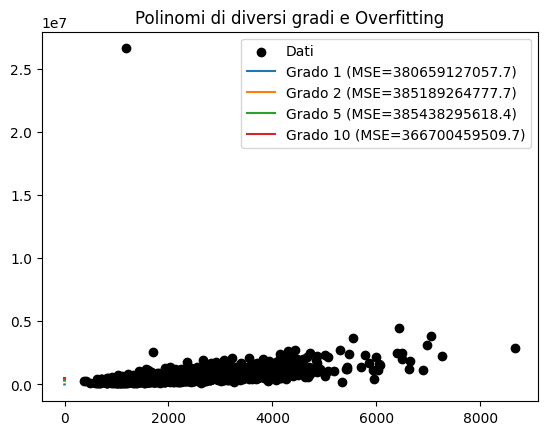

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np


degrees = [1, 2, 5, 10]

plt.scatter(train_df_X, train_df_y, color="black", label="Dati")

X_plot = np.linspace(-5, 5, 200).reshape(-1, 1)

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X_plot)
    X_train_poly = poly.fit_transform(train_df_X)
    lin = LinearRegression().fit(X_train_poly, train_df_y)
    Y_predicted = lin.predict(X_train_poly)
    mse = mean_squared_error(train_df_X,Y_predicted )
    r2_score = lin.score(X_train_poly,train_df_y)
    print(r2_score)
    plt.plot(X_plot, lin.predict(X_poly),       label=f"Grado {d} (MSE={mse:.1f})")

plt.legend()
plt.title("Polinomi di diversi gradi e Overfitting")
plt.show()

# 